In [1]:
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import trange
from tqdm.cli import tqdm

## prepocessing

In [2]:
df_belchonok = pd.read_csv('./preprocessed_data/belchonok.csv')
df_future = pd.read_csv('./preprocessed_data/future.csv')
df_granit = pd.read_csv('./preprocessed_data/granit_nauki.csv')
df_innopolis = pd.read_csv('./preprocessed_data/innopolis.csv')
df_itmo = pd.read_csv('./preprocessed_data/itmo.csv')
df_mosh = pd.read_csv('./preprocessed_data/mosh.csv')
df_open = pd.read_csv('./preprocessed_data/open.csv')
df_vuz = pd.read_csv('./preprocessed_data/vuz_akadem.csv')
df_mow_sch = pd.read_csv('./preprocessed_data/MOW_SCH.csv')
df_mow_mun = pd.read_csv('./preprocessed_data/MOW_MUN.csv')
df_reg = pd.read_csv('./preprocessed_data/reg.csv')
df_arso_fin = pd.read_csv('./preprocessed_data/fin.csv')

### Фильтрация по участникам

In [3]:
df_arso_fin = df_arso_fin.sort_values(by=['year', 'score'], ascending=[True, False])
df_arso_fin.head()

,place,name,region,class_study,p1,p2,p3,p4,p5,p6,p7,p8,score,title,year
0,1,Грекова Д.,Москва,11,100,100,100,70,100,88,86,80,724,1,24-25
1,2,Абдуллин Г.,Республика Татарстан,11,100,100,100,70,100,100,70,80,720,1,24-25
2,3,Жиганов В.,Москва,10,100,100,88,60,100,100,66,68,682,1,24-25
3,4,Звездин В.,Санкт-Петербург,10,100,100,100,70,100,76,66,64,676,1,24-25
4,5,Иванов Н.,Москва,11,100,100,88,65,100,100,65,50,668,1,24-25


#### Проблема с совпадением фамилия + первая буква имени

In [4]:
names = df_arso_fin['name'].value_counts().keys().to_numpy()

In [5]:
names[df_arso_fin['name'].value_counts() > 2]

array(['Закиров А.', 'Макаров М.', 'Торба А.', 'Соколов М.', 'Андреев А.',
       'Зайцев А.', 'Осипов Д.'], dtype=object)

In [6]:
df_arso_fin['name'].value_counts()

name
Закиров А.         4
Макаров М.         4
Торба А.           3
Соколов М.         3
Андреев А.         3
                  ..
Александров М.     1
Дружинина А.       1
Шарафутдинов Р.    1
Воронков Е.        1
Казанский Р.       1
Name: count, Length: 719, dtype: int64

In [7]:
df_arso_fin[df_arso_fin['name'].isin(names[df_arso_fin['name'].value_counts() > 2])].sort_values(by=['place'], ascending=[True])

,place,name,region,class_study,p1,p2,p3,p4,p5,p6,p7,p8,score,title,year
505,13,Макаров М.,Москва,11,100,100,26,40,100,100,89,34,589,1.0,25-26
508,16,Макаров М.,Москва,11,100,100,20,31,100,95,100,25,571,1.0,25-26
28,29,Макаров М.,Москва,10,100,100,63,0,100,100,65,60,588,1,24-25
528,35,Закиров А.,Республика Татарстан,10,100,100,26,35,100,85,59,32,537,1.0,25-26
41,41,Закиров А.,Республика Татарстан,9,100,100,63,44,100,71,55,33,566,2,24-25
534,42,Закиров А.,Республика Татарстан,11,100,100,20,32,100,85,59,34,530,2.0,25-26
98,99,Торба А.,Москва,10,100,86,49,30,100,66,40,46,517,2,24-25
107,108,Закиров А.,Республика Татарстан,10,100,100,51,16,100,76,50,17,510,2,24-25
604,111,Торба А.,Москва,11,100,46,26,41,100,85,59,25,482,2.0,25-26
606,113,Андреев А.,Ростовская область,11,100,51,26,35,100,85,59,25,481,2.0,25-26


**РЕШЕНИЕ**:
слииив

In [8]:
df_arso_fin=df_arso_fin[df_arso_fin['year'] == '24-25']
df_arso_fin=df_arso_fin.drop(columns=['region', 'year', 'title']).groupby('name', as_index=False).mean()
df_arso_fin.sort_values(by=['place'], inplace=True)
df_arso_fin[10:30]

,name,place,class_study,p1,p2,p3,p4,p5,p6,p7,p8,score
444,Цыбань Л.,11.0,10.0,100.0,100.0,80.0,44.0,100.0,100.0,61.0,50.0,635.0
210,Кравченко М.,11.0,9.0,100.0,100.0,80.0,30.0,100.0,100.0,67.0,58.0,635.0
41,Бессолицын М.,13.0,11.0,100.0,100.0,91.0,30.0,100.0,88.0,69.0,50.0,628.0
441,Ходыкин Т.,14.0,11.0,100.0,100.0,60.0,30.0,100.0,100.0,64.0,68.0,622.0
477,Щербаков М.,15.0,11.0,100.0,100.0,87.0,36.0,100.0,100.0,64.0,33.0,620.0
98,Гришко Д.,16.0,10.0,100.0,100.0,87.0,16.0,100.0,100.0,70.0,46.0,619.0
258,Малыгин А.,17.0,10.0,100.0,100.0,73.0,30.0,100.0,100.0,53.0,60.0,616.0
369,Свирид Е.,17.0,11.0,100.0,100.0,73.0,36.0,100.0,83.0,64.0,60.0,616.0
373,Семенюк Я.,17.0,11.0,100.0,100.0,63.0,30.0,100.0,100.0,78.0,45.0,616.0
221,Кузнецов И.,20.0,10.0,100.0,100.0,88.0,30.0,100.0,71.0,64.0,60.0,613.0


In [9]:
df_arso_fin

,name,place,class_study,p1,p2,p3,p4,p5,p6,p7,p8,score
92,Грекова Д.,1.0,11.0,100.0,100.0,100.0,70.0,100.0,88.0,86.0,80.0,724.0
0,Абдуллин Г.,2.0,11.0,100.0,100.0,100.0,70.0,100.0,100.0,70.0,80.0,720.0
124,Жиганов В.,3.0,10.0,100.0,100.0,88.0,60.0,100.0,100.0,66.0,68.0,682.0
139,Звездин В.,4.0,10.0,100.0,100.0,100.0,70.0,100.0,76.0,66.0,64.0,676.0
143,Иванов Н.,5.0,11.0,100.0,100.0,88.0,65.0,100.0,100.0,65.0,50.0,668.0
...,...,...,...,...,...,...,...,...,...,...,...,...
133,Замахин П.,489.0,11.0,0.0,5.0,0.0,0.0,100.0,36.0,0.0,0.0,141.0
72,Воропаев Я.,490.0,10.0,25.0,0.0,0.0,0.0,65.0,36.0,0.0,0.0,126.0
106,Днепровский Е.,491.0,10.0,0.0,5.0,0.0,0.0,100.0,16.0,0.0,0.0,121.0
142,Зулаев Э.,492.0,9.0,50.0,5.0,0.0,0.0,48.0,10.0,0.0,0.0,113.0


In [10]:
dfs = [df_belchonok, df_granit, df_innopolis, df_itmo, df_mosh, df_open, df_vuz, df_mow_sch, df_mow_mun, df_reg, df_future]

In [11]:
for i in range(len(dfs) - 1):
    j = dfs[i]
    num_cols = j.select_dtypes(include='number').columns.tolist()
    j[num_cols] = j[num_cols].fillna(0)
    j = j[j['name'].isin(df_arso_fin['name'].to_numpy())]
    j = j[j['year'] == '24-25']
    dfs[i] = j
dfs[10] = dfs[10][dfs[10]['name'].isin(df_arso_fin['name'].to_numpy())]

In [12]:
dfs[5]

,name,grade,participation_grade,reg,A1,B1,C1,D1,A2,B2,C2,D2,total,result,year
0,Лосев П.,11,11,Москва,83.0,100.0,100.0,100.0,78.0,100.0,100.0,100.0,761,3,24-25
1,Абдуллин Г.,11,11,Казань,100.0,100.0,100.0,100.0,45.0,100.0,100.0,46.0,691,3,24-25
2,Звездин В.,10,11,Санкт-Петербург,83.0,100.0,100.0,100.0,45.0,100.0,100.0,52.0,680,3,24-25
3,Грекова Д.,11,11,Москва,93.0,72.0,100.0,100.0,45.0,100.0,100.0,22.0,632,3,24-25
4,Цыбань Л.,10,11,Москва,36.0,62.0,100.0,100.0,32.0,100.0,100.0,100.0,630,3,24-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,Гапичев Я.,9,11,Липецк,0.0,0.0,8.0,14.0,0.0,79.0,0.0,4.0,105,0,24-25
410,Островский А.,10,11,Ижевск,0.0,4.0,0.0,0.0,0.0,100.0,0.0,0.0,104,0,24-25
411,Ражабов С.,10,11,Москва,13.0,4.0,8.0,0.0,0.0,60.0,15.0,4.0,104,0,24-25
412,Липин И.,10,11,Каменск-Уральский,0.0,12.0,21.0,0.0,0.0,69.0,0.0,0.0,102,0,24-25


In [13]:
l = dfs[9].columns[3:-2]
for i in l:
    dfs[9][i] = dfs[9][i].replace('?', np.nan)
    j = dfs[9][i].astype(float)
    j = j.fillna(0)
    dfs[9][i] = j
    dfs[9].rename({i: i + '1'})
dfs[9]

,name,region,grade,A1,B1,C1,D1,A2,B2,C2,D2,Sum,year
0,Алексеев И.,Санкт-Петербург,10,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,800.0,24-25
1,Звездин В.,Санкт-Петербург,10,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,800.0,24-25
2,Кузнецов Е.,Липецкая область,9,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,800.0,24-25
3,Часовских И.,Сириус,11,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,800.0,24-25
4,Янковский А.,Москва,9,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,800.0,24-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6727,Васильев А.,Чувашская Республика,11,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,18.0,24-25
7172,Зайцев А.,Ставропольский край,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24-25
7215,Карпов А.,Брянская область,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24-25
7392,Мирошниченко А.,Краснодарский край,11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24-25


Не смотрите в эти макароны - опасно, возможен вывих глаза

In [14]:
alll = dfs[0]
alll = pd.merge(alll, dfs[1], on='name', how='outer')
alll = pd.merge(alll, dfs[2], on='name', how='outer').drop(columns=['result', 'reg_y', 'reg_x', 'year', 'year_y', 'year_x']).rename(columns={'total_x': 'total1', 'total_y': 'total2', 'grade_x': 'grade1', 'grade_y': 'grade2', 'result_x': 'result1', 'result_y': 'result2'})
alll = pd.merge(alll, dfs[3], on='name', how='outer').drop(columns=['year']).rename(columns={'score': 'score1'})
alll = pd.merge(alll, dfs[4].drop(columns=['class_study']), on='name', how='outer').drop(columns=['id', 'year',  'title', 'reg']).rename(columns={'result': 'result3', 'grade': 'grade3', 'total': 'total3'})
alll = pd.merge(alll, dfs[5], on='name', how='outer').drop(columns=['reg', 'year']).rename(columns={'result': 'result4', 'grade': 'grade4', 'total': 'total4', 'score': 'score4'})
alll = pd.merge(alll, dfs[6], on='name', how='outer').drop(columns=['reg', 'year', 'region', 'class_partake'])
alll = pd.merge(alll, dfs[7].drop(columns=['class_study']), on='name', how='outer').drop(columns=['id', 'year', 'class_partake', 'region', 'title', 'participation_grade']).rename(columns={'result': 'result5', 'grade': 'grade5', 'total': 'total5', 'score': 'score5'})
alll = pd.merge(alll, dfs[8], on='name', how='outer').drop(columns=['year', 'region'])
alll = pd.merge(alll, dfs[9], on='name', how='outer').drop(columns=['year', 'title', 'region', 'grade'])
alll = pd.merge(alll, dfs[10], on='name', how='outer').drop(columns=['class_study', 'grade1', 'total2'])
alll

,name,total1,result1,result2,total3,grade2,stage,A,B,C,...,D1_y,A2_y,B2_y,C2_y,D2_y,Sum,place,id_y,title,grade
0,Абдуллин Г.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,100.0,100.0,100.0,100.0,61.0,761.0,NaN,NaN,NaN,NaN
1,Абубакиров Б.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,70.0,100.0,100.0,100.0,53.0,723.0,NaN,NaN,NaN,NaN
2,Абульхаеров С.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,100.0,100.0,100.0,53.0,589.0,NaN,NaN,NaN,NaN
3,Агафонов М.,NaN,NaN,NaN,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,78.0,100.0,100.0,0.0,578.0,NaN,NaN,NaN,NaN
4,Адаменко М.,NaN,NaN,NaN,0.0,11.0,2.0,0.0,0.0,0.0,...,7.0,100.0,100.0,100.0,20.0,627.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,Юсуфов И.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,100.0,100.0,100.0,9.0,549.0,NaN,NaN,NaN,NaN
2642,Янко А.,NaN,NaN,NaN,0.0,0.0,2.0,0.0,0.0,0.0,...,55.0,100.0,100.0,100.0,61.0,716.0,NaN,NaN,NaN,NaN
2643,Янковский А.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,100.0,100.0,100.0,100.0,100.0,800.0,NaN,NaN,NaN,NaN
2644,Янковский Д.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,100.0,100.0,100.0,100.0,53.0,753.0,NaN,NaN,NaN,NaN


In [15]:
alll = alll.groupby('name', as_index=False).mean()

In [16]:
#alll.to_csv('learn_data.csv')

In [17]:
alll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 46 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           486 non-null    object 
 1   total1         6 non-null      float64
 2   result1        6 non-null      float64
 3   result2        0 non-null      float64
 4   total3         235 non-null    float64
 5   grade2         235 non-null    float64
 6   stage          235 non-null    float64
 7   A              235 non-null    float64
 8   B              235 non-null    float64
 9   C              235 non-null    float64
 10  D              235 non-null    float64
 11  E              235 non-null    float64
 12  F              235 non-null    float64
 13  result3        11 non-null     float64
 14  grade3         11 non-null     float64
 15  score4         0 non-null      float64
 16  grade4         285 non-null    float64
 17  A1_x           285 non-null    float64
 18  B1_x      

In [18]:
dfs[10]

,place,id,name,title,grade
1,1,33114,Аргунов И.,1,11
12,12,46842,Кулаков А.,1,11
17,17,86307,Михайлов И.,1,11
20,20,75770,Панин И.,1,11
62,62,29136,Непеин М.,2,11
67,67,66706,Осипов Д.,2,11
68,68,75009,Павлов Н.,2,11
69,69,89521,Пакканен Д.,2,11
71,71,68631,Петров Е.,2,11
89,89,44807,Чаунин М.,2,11


In [19]:
X = alll.drop(columns=['name', 'place'])
y = df_arso_fin[df_arso_fin['name'].isin(alll['name'])].sort_index()['place']

In [20]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

In [21]:
model = CatBoostRegressor(verbose=50, random_seed=42).fit(X, y)

Learning rate set to 0.036532
0:	learn: 139.7443313	total: 50.3ms	remaining: 50.3s
50:	learn: 90.8867550	total: 114ms	remaining: 2.11s
100:	learn: 81.4209058	total: 169ms	remaining: 1.5s
150:	learn: 76.8706223	total: 223ms	remaining: 1.26s
200:	learn: 72.6668970	total: 287ms	remaining: 1.14s
250:	learn: 69.1409255	total: 355ms	remaining: 1.06s
300:	learn: 65.9397006	total: 431ms	remaining: 1s
350:	learn: 62.4922267	total: 518ms	remaining: 958ms
400:	learn: 59.8657960	total: 584ms	remaining: 873ms
450:	learn: 57.0500020	total: 642ms	remaining: 781ms
500:	learn: 54.2891287	total: 696ms	remaining: 694ms
550:	learn: 51.6121411	total: 752ms	remaining: 613ms
600:	learn: 49.1403516	total: 806ms	remaining: 535ms
650:	learn: 46.8610260	total: 859ms	remaining: 461ms
700:	learn: 44.8900188	total: 914ms	remaining: 390ms
750:	learn: 42.9467882	total: 996ms	remaining: 330ms
800:	learn: 41.3467612	total: 1.05s	remaining: 262ms
850:	learn: 39.9457955	total: 1.1s	remaining: 193ms
900:	learn: 38.2698507

In [104]:
X_test = pd.read_csv('learn_data.csv').drop(columns=['Unnamed: 0'])
y_test = pd.read_csv('preprocessed_data/fin.csv')
y_test = y_test[y_test['year'] == '25-26']
all_names = y_test['name']
y_test = y_test.sort_values(by='name').drop(columns=['region', 'year', 'title'])
pozorniki = y_test[~y_test['name'].isin(X_test['name'])]['name']
duplicates = y_test[y_test['name'].duplicated()]['name']
names = y_test['name'].unique()
y_test = y_test['place']
X_test = pd.concat([X_test, pd.DataFrame({'name': pozorniki})])
X_test = X_test.sort_index()
X_test = X_test.drop(columns=['name', 'place'])
print(f'pozorniki: {pozorniki.shape}, duplicates: {duplicates.shape}')
X_test.shape, y_test.shape

pozorniki: (5,), duplicates: (6,)


((480, 44), (486,))

In [105]:
all_names

493      Звездин В.
494     Кузнецов Е.
495    Приводнов М.
496      Жиганов В.
497    Кравченко М.
           ...     
974        Зуева А.
975      Кочуров Е.
976        Голов С.
977       Курзин И.
978     Яковлева П.
Name: name, Length: 486, dtype: object

In [83]:
from sklearn.metrics import ndcg_score

y_test = np.array(y_test)
y_pred = model.predict(X_test)

In [118]:
submission = pd.DataFrame({'name': names, 'place': y_pred})
dup_places = []
for i in duplicates:
    tmp = submission[submission['name'] == i]['place']
    dup_places.append(tmp[tmp.index[0]])
dups = pd.DataFrame({'name': duplicates, 'place': dup_places})
submission = pd.concat([submission, dups]).sort_values(by='place')
submission['place'] = 500 - submission['place']
print(f'NDCG: {ndcg_score([y_test], [submission['place']], k=10)}')
submission['target_names'] = np.array(all_names)
submission.to_csv('submission.csv', index=False)
submission

NDCG: 0.7304114533537069


,name,place,target_names
285,Мусихин М.,490.447922,Звездин В.
147,Захарочкина К.,488.245401,Кузнецов Е.
98,Гриненко А.,479.495532,Приводнов М.
133,Жабатинский И.,465.613514,Жиганов В.
473,Элмуродов У.,458.134285,Кравченко М.
...,...,...,...
391,Тальков Я.,46.284689,Зуева А.
162,Истяков М.,44.294100,Кочуров Е.
419,Фендеров О.,44.081664,Голов С.
312,Орлов С.,43.337258,Курзин И.


<Axes: >

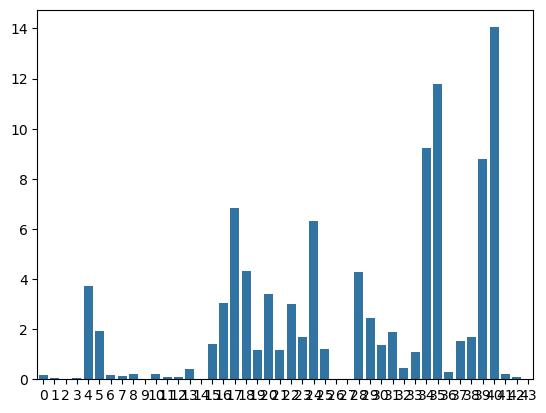

In [29]:
import seaborn as sb

sb.barplot(model.feature_importances_)

In [33]:
pd.DataFrame({'feat': X_test.columns, 'imp': model.feature_importances_}).sort_values(by='imp', ascending=False)

,feat,imp
40,Sum,14.046443
35,D1_y,11.799432
34,C1_y,9.217676
39,D2_y,8.784037
17,B1_x,6.845818
24,total4,6.318873
18,C1_x,4.319905
28,score5,4.278395
4,grade2,3.709823
20,A2_x,3.390012
